# 031 — High-Repetition Distribution Analysis (R=1000)

Three GPQA tasks (q84, q125, q144), W=2, FC, N=4, R=1000 each.
Goal: characterise the outcome distribution and identify run-level features
that predict accuracy and efficiency.

Figures exported to `thesis/plots/highrep/` for inclusion in the thesis.


In [1]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import (entropy as scipy_entropy, pointbiserialr, pearsonr,
                         chi2_contingency, gaussian_kde)

BASE   = Path('..') / 'results' / 'mas' / 'high_repetition'
EXPORT = Path('..') / 'thesis'  / 'plots' / 'highrep'
EXPORT.mkdir(parents=True, exist_ok=True)

TASKS  = ['84', '125', '144']
COLORS = {'84': '#0072B2', '125': '#E69F00', '144': '#009E73'}
LABELS = {'84': 'q84 (acc=0.27)', '125': 'q125 (acc=0.27)', '144': 'q144 (acc=0.51)'}
T_CEIL = 15

from src.viz.thesis_style import apply_style, no_grid
apply_style()
print('setup ok')

setup ok


In [2]:
def vote_entropy(votes, options):
    counts = np.array([votes.count(o) for o in options], dtype=float)
    p = counts / counts.sum()
    return float(scipy_entropy(p, base=2))

def extract_rep(rep, gt, options):
    traj = rep['trajectory']; N = rep['N']
    v0 = [ag['vote'] for ag in traj[0]['phase_b']]
    vf = [ag['vote'] for ag in traj[-1]['phase_b']]
    c0 = [ag['confidence'] for ag in traj[0]['phase_b']]
    cf = [ag['confidence'] for ag in traj[-1]['phase_b']]
    maj0 = max(options, key=lambda o: v0.count(o))
    majf = max(options, key=lambda o: vf.count(o))
    n_flips = 0
    for aid in range(N):
        prev = traj[0]['phase_b'][aid]['vote']
        for t in range(1, len(traj)):
            curr = traj[t]['phase_b'][aid]['vote']
            if curr != prev: n_flips += 1
            prev = curr
    return {
        'correct':               int(rep['correct']),
        'rounds':                len(traj) - 1,
        'h0':                    vote_entropy(v0, options),
        'majority_size_0':       v0.count(maj0),
        'mean_conf_0':           float(np.mean(c0)),
        'n_flips':               n_flips,
        'mean_conf_final':       float(np.mean(cf)),
        'conf_delta':            float(np.mean(cf)) - float(np.mean(c0)),
        'gt_is_init_majority':   int(maj0 == gt),
        'gt_in_init_votes':      int(gt in v0),
        'init_vote_acc':         v0.count(gt) / len(v0),
        'init_majority_persists': int(maj0 == majf),
        'gt': gt,
    }

dfs, metas = {}, {}
for qid in TASKS:
    f = next(BASE.glob(f'*_q{qid}_*.json'))
    d = json.loads(f.read_text())
    options = list(d['options'].keys()); gt = d['ground_truth']
    rows = [extract_rep(r, gt, options) for r in d['repetitions']]
    dfs[qid] = pd.DataFrame(rows)
    metas[qid] = {'gt': gt, 'options': options, 'q': d['question'][:80]}
    df = dfs[qid]
    print(f"q{qid} (gt={gt}): acc={df['correct'].mean():.3f}  "
          f"mean_rounds={df['rounds'].mean():.2f}  "
          f"gt_in_votes={df['gt_in_init_votes'].mean():.3f}  "
          f"gt_is_maj={df['gt_is_init_majority'].mean():.3f}")
print(f"\ntotal rows: {sum(len(dfs[q]) for q in TASKS)}")

q84 (gt=C): acc=0.269  mean_rounds=4.52  gt_in_votes=0.743  gt_is_maj=0.213


q125 (gt=C): acc=0.273  mean_rounds=4.65  gt_in_votes=0.707  gt_is_maj=0.250


q144 (gt=C): acc=0.509  mean_rounds=4.22  gt_in_votes=0.856  gt_is_maj=0.403

total rows: 3000


In [3]:
def wilson_ci(k, n, z=1.96):
    if n == 0: return (0.0, 0.0)
    p = k / n; denom = 1 + z**2/n
    centre = (p + z**2/(2*n)) / denom
    half = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return float(max(0, centre-half)), float(min(1, centre+half))

def binned_stat(df, feat, stat_col, n_bins=12, x_range=None, min_n=10):
    df = df.copy()
    if x_range:
        bins = np.linspace(x_range[0], x_range[1], n_bins+1)
        df['bin'] = pd.cut(df[feat], bins)
    else:
        try: df['bin'] = pd.qcut(df[feat], n_bins, duplicates='drop')
        except: df['bin'] = pd.cut(df[feat], n_bins)
    rows = []
    for b, g in df.groupby('bin', observed=True):
        if len(g) < min_n: continue
        mid = (b.left + b.right) / 2; n = len(g); k = g[stat_col].sum()
        if stat_col == 'correct':
            val = k/n; lo, hi = wilson_ci(k, n)
        else:
            val = g[stat_col].mean(); sem = g[stat_col].sem()
            lo, hi = val - sem, val + sem
        rows.append({'mid': mid, 'val': val, 'lo': lo, 'hi': hi, 'n': n})
    return pd.DataFrame(rows).sort_values('mid')

print('helpers ok')

helpers ok


## 1. Marginal distributions

H₀ takes only 5 discrete values for N=4 agents with 4 options.


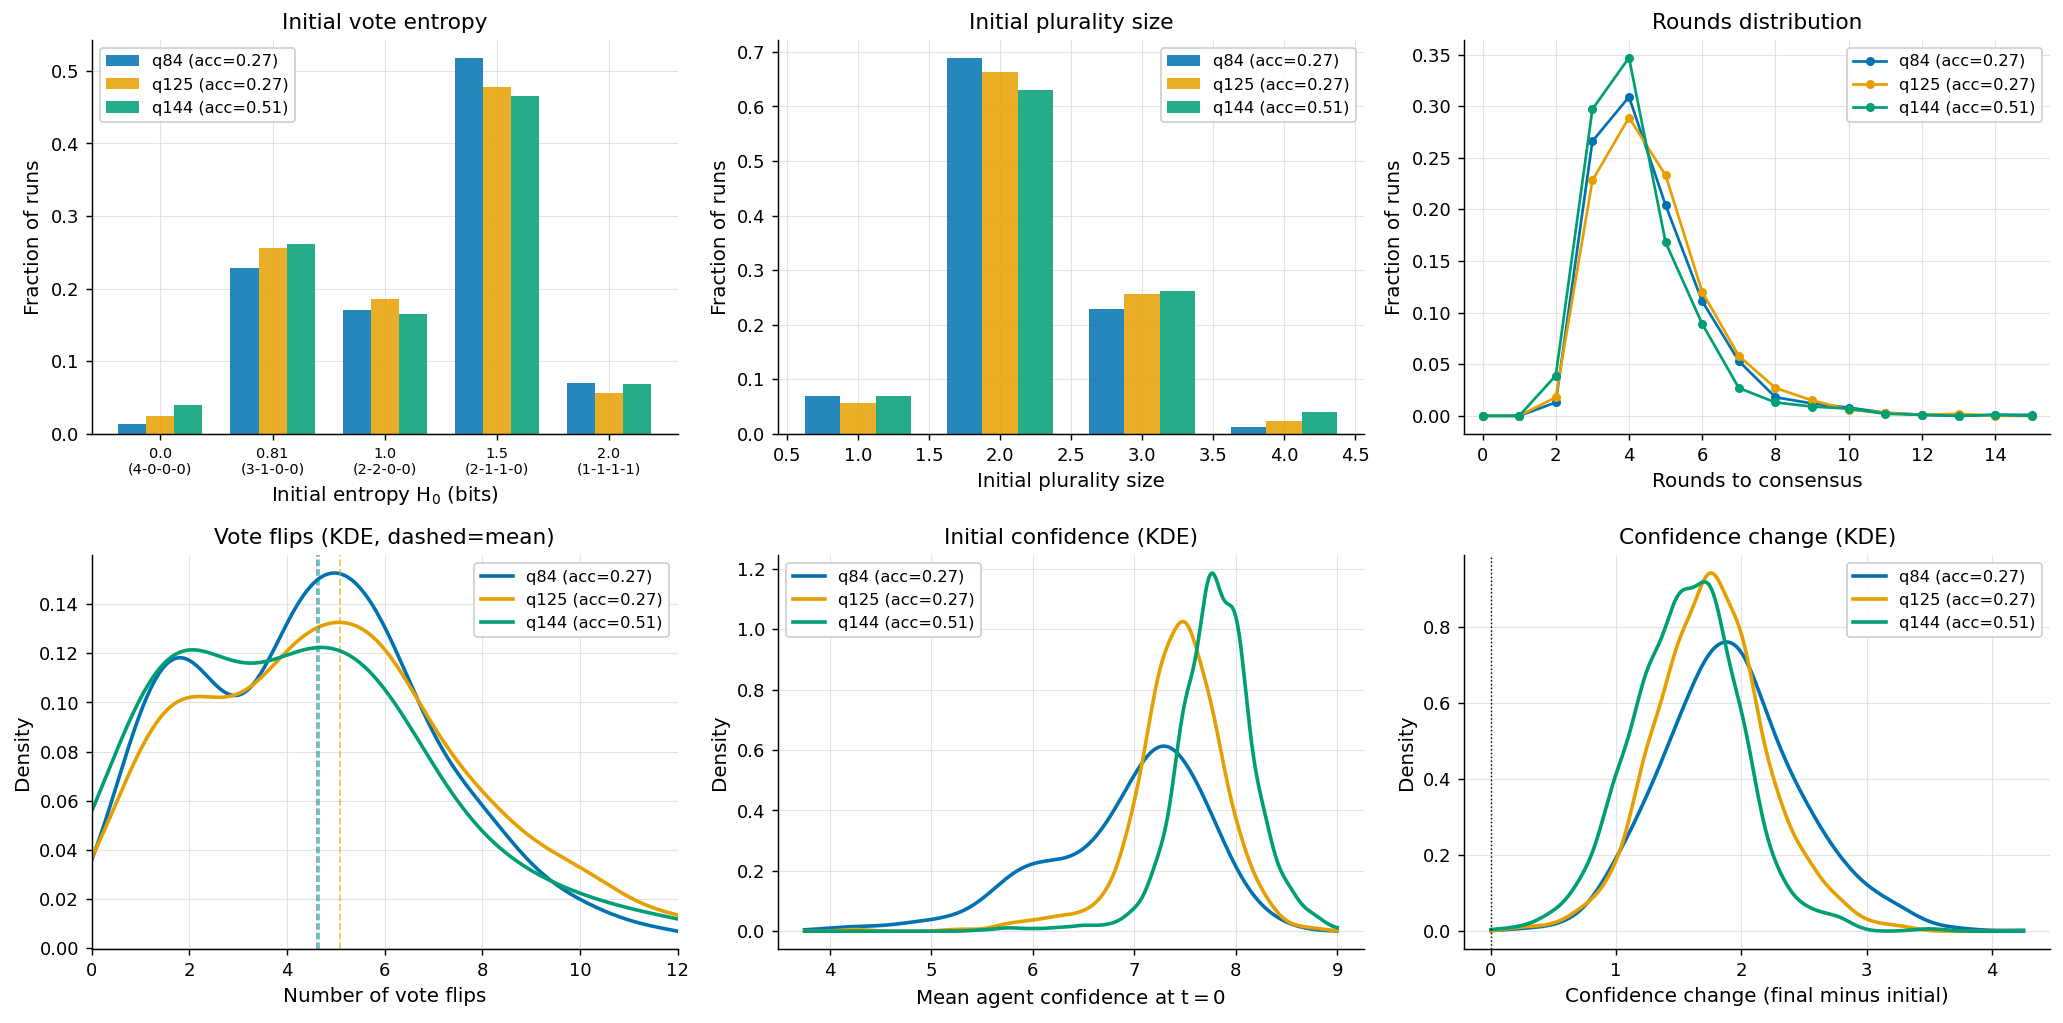

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

H0_VALS  = [0.0, 0.8113, 1.0, 1.5, 2.0]
H0_TICKS = ['0.0\n(4-0-0-0)', '0.81\n(3-1-0-0)', '1.0\n(2-2-0-0)',
            '1.5\n(2-1-1-0)', '2.0\n(1-1-1-1)']
x = np.arange(len(H0_VALS)); w = 0.25

for i, qid in enumerate(TASKS):
    df = dfs[qid]
    counts = [np.sum(np.isclose(df['h0'], v, atol=0.001)) for v in H0_VALS]
    axes[0][0].bar(x+(i-1)*w, np.array(counts)/len(df), w,
                   label=LABELS[qid], color=COLORS[qid], alpha=0.85)
axes[0][0].set_xticks(x); axes[0][0].set_xticklabels(H0_TICKS, fontsize=8)
axes[0][0].set_xlabel('Initial entropy $H_0$ (bits)')
axes[0][0].set_ylabel('Fraction of runs')
axes[0][0].set_title('Initial vote entropy'); axes[0][0].legend(fontsize=9)

ms_vals = [1, 2, 3, 4]
for i, qid in enumerate(TASKS):
    df = dfs[qid]
    fracs = [np.mean(df['majority_size_0'] == v) for v in ms_vals]
    axes[0][1].bar(np.array(ms_vals)+(i-1)*0.25, fracs, 0.25,
                   label=LABELS[qid], color=COLORS[qid], alpha=0.85)
axes[0][1].set_xlabel('Initial plurality size')
axes[0][1].set_ylabel('Fraction of runs')
axes[0][1].set_title('Initial plurality size'); axes[0][1].legend(fontsize=9)

bins_r = np.arange(0, T_CEIL+2) - 0.5
for qid in TASKS:
    df = dfs[qid]
    counts, _ = np.histogram(df['rounds'], bins=bins_r)
    axes[0][2].plot(np.arange(0, T_CEIL+1), counts/len(df), 'o-',
                    color=COLORS[qid], label=LABELS[qid], ms=4, lw=1.5)
axes[0][2].set_xlabel('Rounds to consensus'); axes[0][2].set_ylabel('Fraction of runs')
axes[0][2].set_title('Rounds distribution'); axes[0][2].legend(fontsize=9)
axes[0][2].set_xlim(-0.5, T_CEIL+0.5)

flip_p95 = max(np.percentile(dfs[qid]['n_flips'], 97) for qid in TASKS)
xf = np.linspace(0, flip_p95, 300)
for qid in TASKS:
    kde = gaussian_kde(dfs[qid]['n_flips'], bw_method=0.3)
    axes[1][0].plot(xf, kde(xf), color=COLORS[qid], lw=2, label=LABELS[qid])
    axes[1][0].axvline(dfs[qid]['n_flips'].mean(), color=COLORS[qid], lw=1, ls='--', alpha=0.6)
axes[1][0].set_xlabel('Number of vote flips'); axes[1][0].set_ylabel('Density')
axes[1][0].set_title('Vote flips (KDE, dashed=mean)'); axes[1][0].legend(fontsize=9)
axes[1][0].set_xlim(0, flip_p95)

conf_min = min(dfs[qid]['mean_conf_0'].min() for qid in TASKS)
conf_max = max(dfs[qid]['mean_conf_0'].max() for qid in TASKS)
xc = np.linspace(conf_min, conf_max, 300)
for qid in TASKS:
    kde = gaussian_kde(dfs[qid]['mean_conf_0'], bw_method=0.3)
    axes[1][1].plot(xc, kde(xc), color=COLORS[qid], lw=2, label=LABELS[qid])
axes[1][1].set_xlabel('Mean agent confidence at $t=0$'); axes[1][1].set_ylabel('Density')
axes[1][1].set_title('Initial confidence (KDE)'); axes[1][1].legend(fontsize=9)

cd_min = min(dfs[qid]['conf_delta'].min() for qid in TASKS)
cd_max = max(dfs[qid]['conf_delta'].max() for qid in TASKS)
xd = np.linspace(cd_min, cd_max, 300)
for qid in TASKS:
    kde = gaussian_kde(dfs[qid]['conf_delta'], bw_method=0.3)
    axes[1][2].plot(xd, kde(xd), color=COLORS[qid], lw=2, label=LABELS[qid])
axes[1][2].axvline(0, color='k', lw=0.8, ls=':')
axes[1][2].set_xlabel('Confidence change (final minus initial)'); axes[1][2].set_ylabel('Density')
axes[1][2].set_title('Confidence change (KDE)'); axes[1][2].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 2. Initial vote composition: the dominant predictor

**Thesis figure 1.** Whether the ground-truth answer is present in the initial
vote distribution is the single strongest predictor of final accuracy.


In [5]:
from scipy.stats import chi2_contingency

print('gt_in_init_votes effect:\n')
for qid in TASKS:
    df = dfs[qid]
    y = df[df['gt_in_init_votes']==1]; n = df[df['gt_in_init_votes']==0]
    ct = np.array([[y['correct'].sum(), len(y)-y['correct'].sum()],
                   [n['correct'].sum(), len(n)-n['correct'].sum()]])
    chi2, p, _, _ = chi2_contingency(ct)
    print(f"q{qid}: present={y['correct'].mean():.3f}(n={len(y)})  "
          f"absent={n['correct'].mean():.4f}(n={len(n)})  chi2={chi2:.0f} p={p:.1e}")
    m = df[df['gt_is_init_majority']==1]; nm = df[df['gt_is_init_majority']==0]
    print(f"       gt IS plurality={m['correct'].mean():.3f}(n={len(m)})  "
          f"gt NOT plurality={nm['correct'].mean():.3f}(n={len(nm)})")

gt_in_init_votes effect:

q84: present=0.361(n=743)  absent=0.0039(n=257)  chi2=122 p=2.5e-28
       gt IS plurality=0.620(n=213)  gt NOT plurality=0.174(n=787)
q125: present=0.373(n=707)  absent=0.0307(n=293)  chi2=121 p=4.1e-28
       gt IS plurality=0.552(n=250)  gt NOT plurality=0.180(n=750)
q144: present=0.583(n=856)  absent=0.0694(n=144)  chi2=128 p=1.1e-29
       gt IS plurality=0.717(n=403)  gt NOT plurality=0.369(n=597)


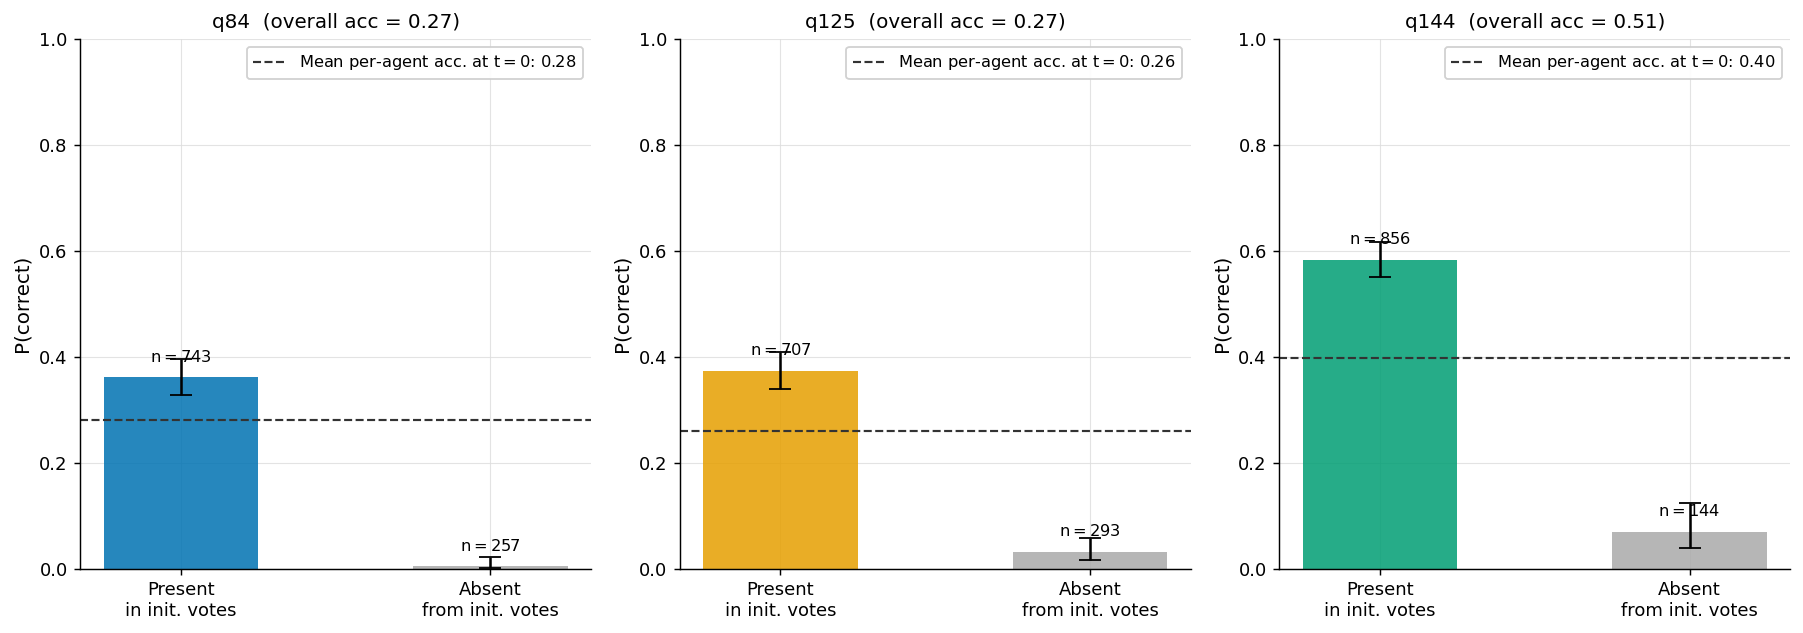

saved fig1_init_votes_split.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, qid in zip(axes, TASKS):
    df = dfs[qid]
    cats   = ['Present\nin init. votes', 'Absent\nfrom init. votes']
    grps   = [df[df['gt_in_init_votes']==1], df[df['gt_in_init_votes']==0]]
    accs   = [g['correct'].mean() for g in grps]
    ns     = [len(g) for g in grps]
    cis    = [wilson_ci(int(a*n), n) for a, n in zip(accs, ns)]

    bars = ax.bar(cats, accs, color=[COLORS[qid], '#aaaaaa'], alpha=0.85, width=0.5)
    ax.errorbar(cats, accs,
                yerr=[[a-c[0] for a,c in zip(accs,cis)],
                      [c[1]-a for a,c in zip(accs,cis)]],
                fmt='none', color='k', capsize=6, lw=1.4)

    init_acc = df['init_vote_acc'].mean()
    ax.axhline(init_acc, color='#333333', lw=1.2, ls='--',
               label=f'Mean per-agent acc. at $t=0$: {init_acc:.2f}')

    ax.set_ylim(0, 1); ax.set_ylabel('P(correct)')
    ax.set_title(f'q{qid}  (overall acc = {df["correct"].mean():.2f})', fontsize=11)
    ax.legend(fontsize=9)
    for bar, n in zip(bars, ns):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
                f'$n={n}$', ha='center', fontsize=9)

plt.tight_layout()
fig.savefig(EXPORT / 'fig1_init_votes_split.png')
plt.show()
print('saved fig1_init_votes_split.png')

## 3. Initial entropy and plurality size vs accuracy and efficiency

**Thesis figure 2.** H₀ and initial plurality size are two representations of the
same structure: higher entropy means a smaller plurality.


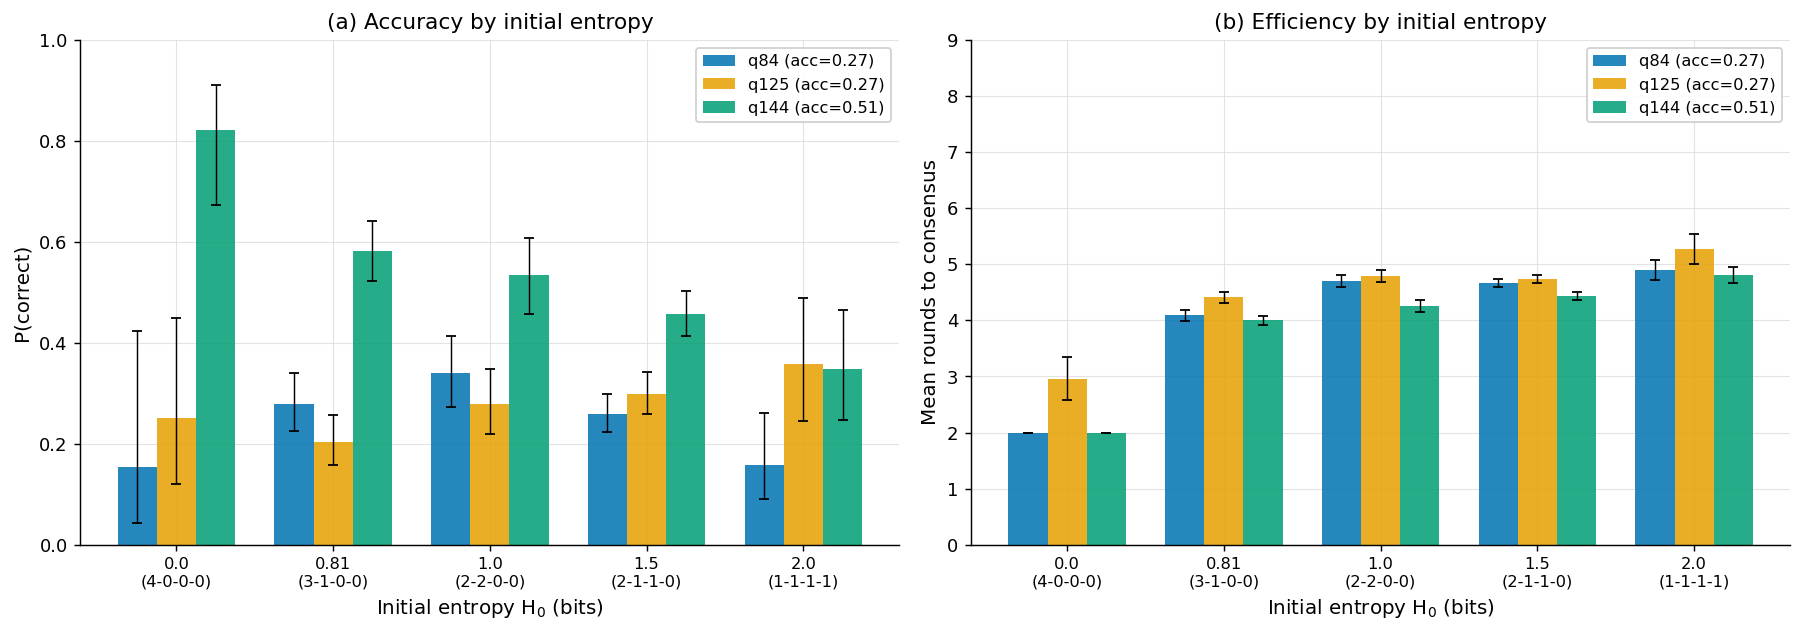

saved fig2_h0_accuracy_efficiency.png


In [7]:
H0_VALS  = [0.0, 0.8113, 1.0, 1.5, 2.0]
H0_TICKS = ['0.0\n(4-0-0-0)', '0.81\n(3-1-0-0)', '1.0\n(2-2-0-0)',
            '1.5\n(2-1-1-0)', '2.0\n(1-1-1-1)']
x = np.arange(len(H0_VALS)); w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: accuracy vs H0 ---
ax = axes[0]
for i, qid in enumerate(TASKS):
    df = dfs[qid]
    accs, los, his = [], [], []
    for v in H0_VALS:
        g = df[np.isclose(df['h0'], v, atol=0.001)]
        k, n = g['correct'].sum(), len(g)
        a = k/n if n else np.nan
        lo, hi = wilson_ci(k, n) if n else (np.nan, np.nan)
        accs.append(a); los.append(lo); his.append(hi)
    accs, los, his = np.array(accs), np.array(los), np.array(his)
    mask = ~np.isnan(accs)
    ax.bar(x[mask]+(i-1)*w, accs[mask], w, color=COLORS[qid], alpha=0.85, label=LABELS[qid])
    ax.errorbar(x[mask]+(i-1)*w, accs[mask],
                yerr=[accs[mask]-los[mask], his[mask]-accs[mask]],
                fmt='none', color='k', capsize=3, lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(H0_TICKS, fontsize=9)
ax.set_ylim(0, 1); ax.set_xlabel('Initial entropy $H_0$ (bits)')
ax.set_ylabel('P(correct)')
ax.set_title('(a) Accuracy by initial entropy')
ax.legend(fontsize=9)

# --- right: mean rounds vs H0 ---
ax = axes[1]
for i, qid in enumerate(TASKS):
    df = dfs[qid]
    means, sems = [], []
    for v in H0_VALS:
        g = df[np.isclose(df['h0'], v, atol=0.001)]['rounds']
        means.append(g.mean() if len(g) else np.nan)
        sems.append(g.sem()  if len(g) > 1 else 0)
    means, sems = np.array(means), np.array(sems)
    mask = ~np.isnan(means)
    ax.bar(x[mask]+(i-1)*w, means[mask], w, color=COLORS[qid], alpha=0.85, label=LABELS[qid])
    ax.errorbar(x[mask]+(i-1)*w, means[mask], yerr=sems[mask],
                fmt='none', color='k', capsize=3, lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(H0_TICKS, fontsize=9)
ax.set_ylim(0, 9); ax.set_xlabel('Initial entropy $H_0$ (bits)')
ax.set_ylabel('Mean rounds to consensus')
ax.set_title('(b) Efficiency by initial entropy')
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(EXPORT / 'fig2_h0_accuracy_efficiency.png')
plt.show()
print('saved fig2_h0_accuracy_efficiency.png')

## 4. Does longer debate produce better answers?

**Thesis figure 3.** P(correct) as a function of rounds to consensus.


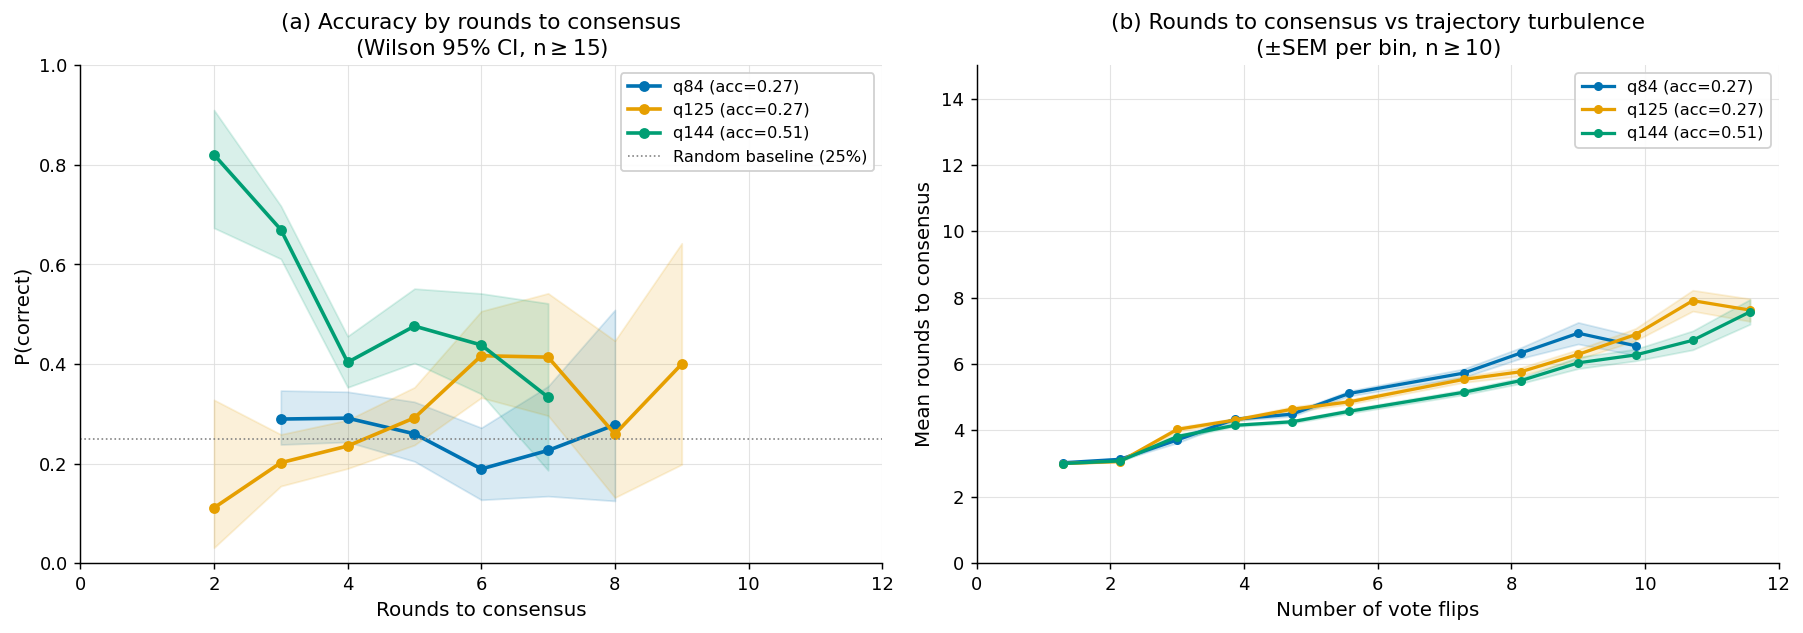

saved fig3_rounds_accuracy_flips.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: P(correct) by rounds
ax = axes[0]
for qid in TASKS:
    df = dfs[qid]
    grp = df.groupby('rounds')['correct'].agg(['mean','count'])
    grp = grp[grp['count'] >= 15]
    lo_ci = [wilson_ci(int(r['mean']*r['count']), int(r['count']))[0]
             for _, r in grp.iterrows()]
    hi_ci = [wilson_ci(int(r['mean']*r['count']), int(r['count']))[1]
             for _, r in grp.iterrows()]
    ax.plot(grp.index, grp['mean'], 'o-', color=COLORS[qid], ms=5, lw=2, label=LABELS[qid])
    ax.fill_between(grp.index, lo_ci, hi_ci, alpha=0.15, color=COLORS[qid])
ax.axhline(0.25, color='gray', lw=0.9, ls=':', label='Random baseline (25%)')
ax.set_xlabel('Rounds to consensus'); ax.set_ylabel('P(correct)')
ax.set_title('(a) Accuracy by rounds to consensus\n(Wilson 95% CI, $n \\geq 15$)')
ax.set_xlim(0, 12); ax.set_ylim(0, 1); ax.legend(fontsize=9)

# right: n_flips vs rounds
ax = axes[1]
flip_p97 = max(np.percentile(dfs[qid]['n_flips'], 97) for qid in TASKS)
for qid in TASKS:
    b = binned_stat(dfs[qid], 'n_flips', 'rounds', n_bins=14, x_range=(0, flip_p97))
    ax.plot(b['mid'], b['val'], 'o-', color=COLORS[qid], ms=4, lw=1.8, label=LABELS[qid])
    ax.fill_between(b['mid'], b['lo'], b['hi'], alpha=0.15, color=COLORS[qid])
ax.set_xlim(0, flip_p97); ax.set_ylim(0, T_CEIL)
ax.set_xlabel('Number of vote flips'); ax.set_ylabel('Mean rounds to consensus')
ax.set_title('(b) Rounds to consensus vs trajectory turbulence\n($\\pm$SEM per bin, $n \\geq 10$)')
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(EXPORT / 'fig3_rounds_accuracy_flips.png')
plt.show()
print('saved fig3_rounds_accuracy_flips.png')

## 5. Full feature breakdown (appendix figures)

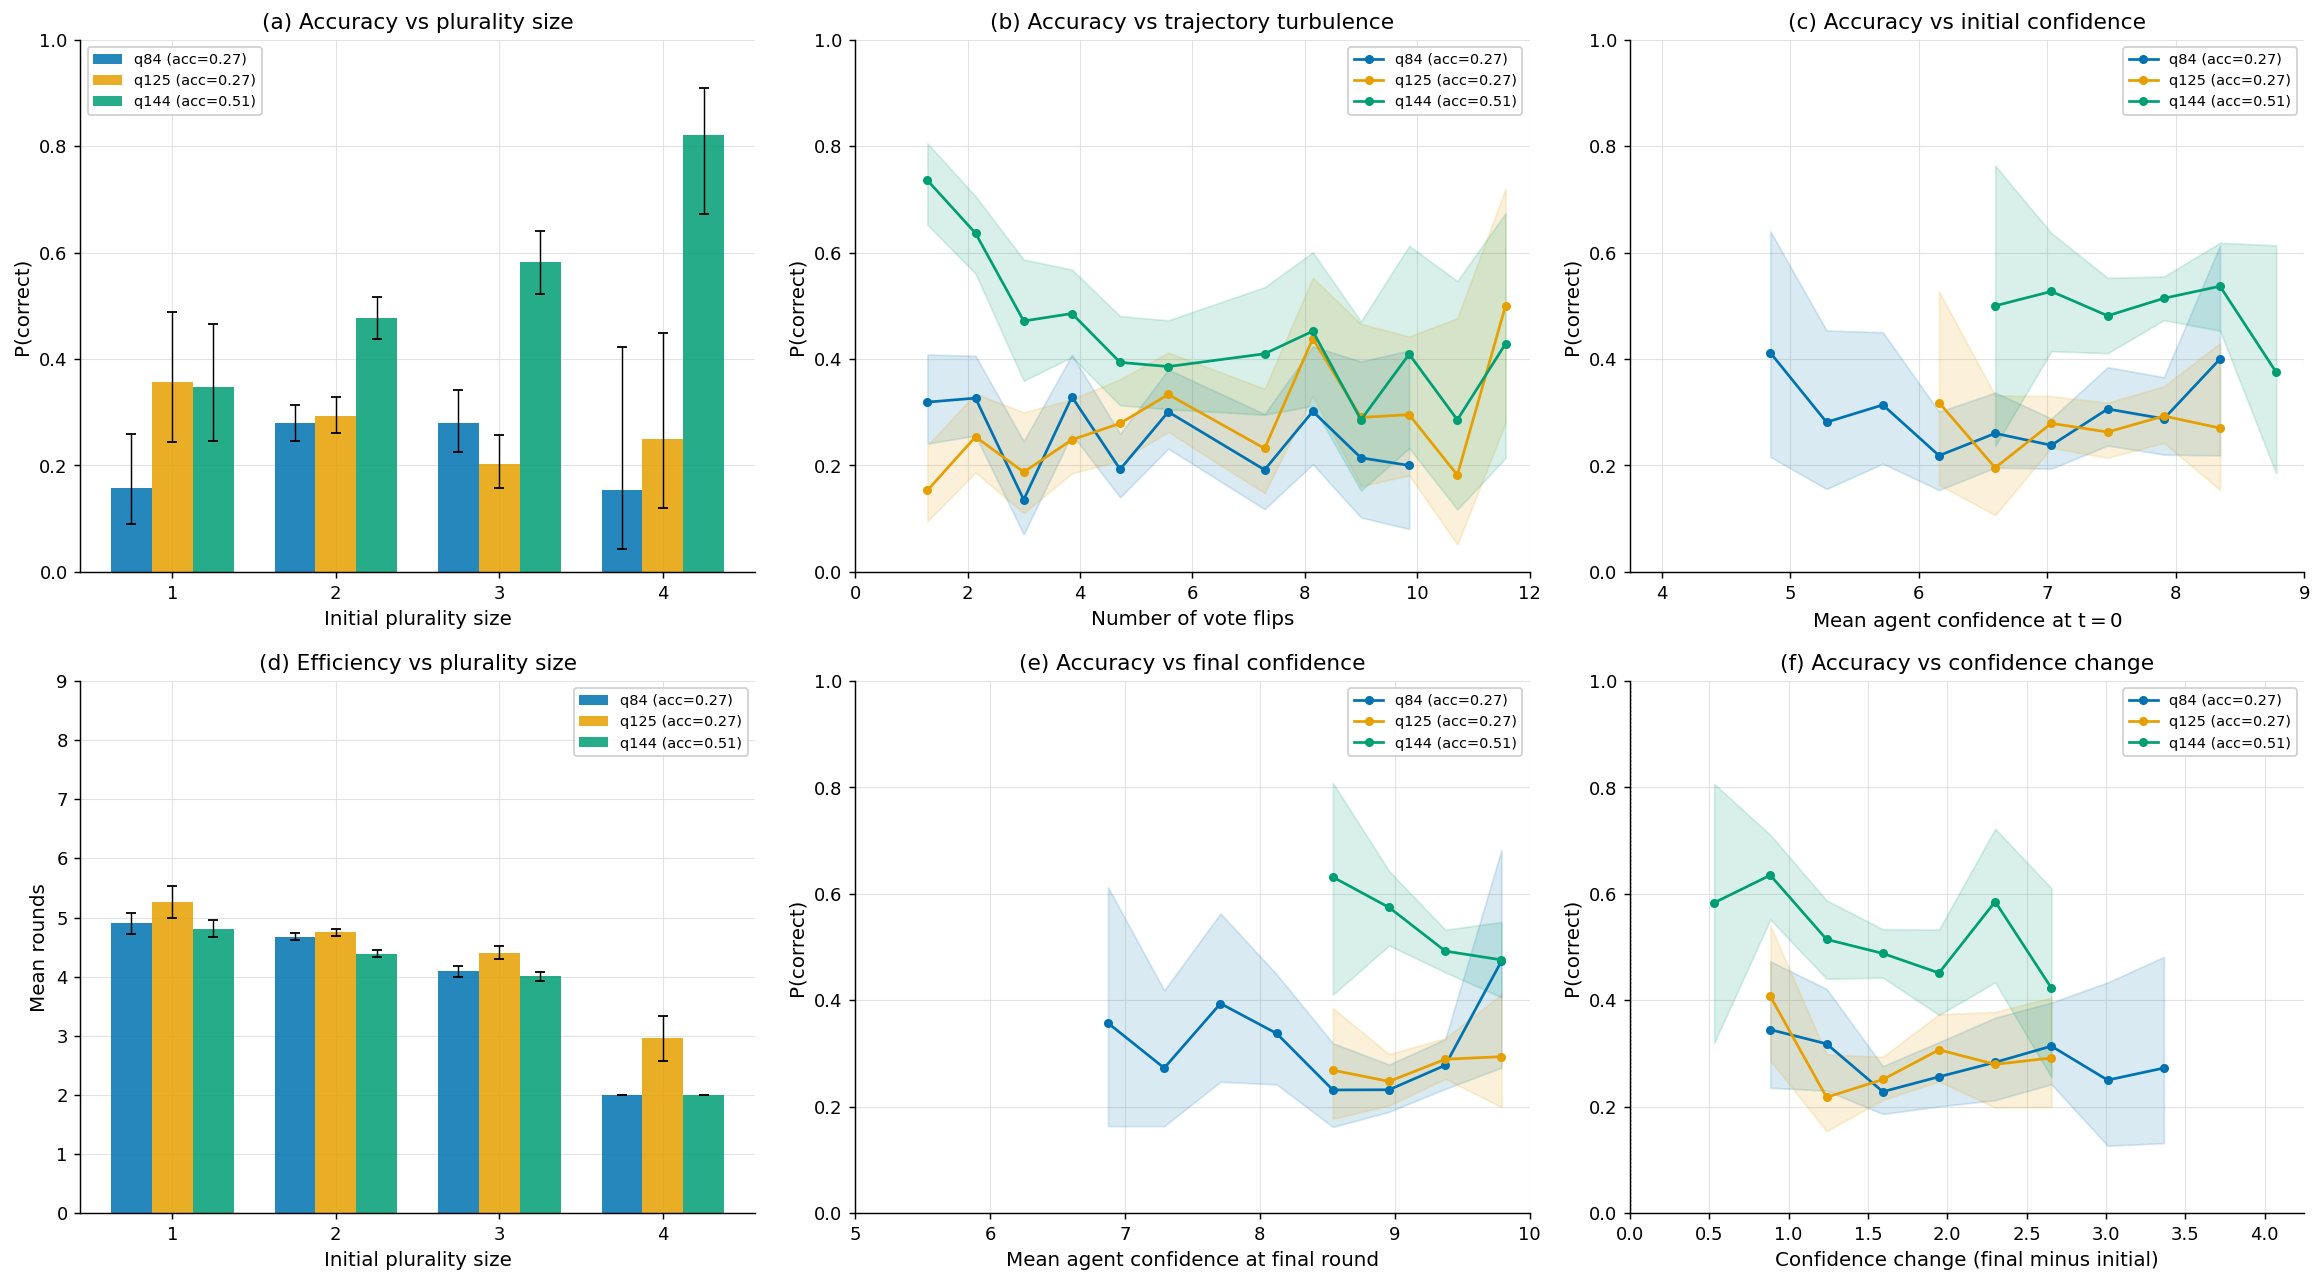

saved figA_full_feature_breakdown.png


In [9]:
flip_p97 = max(np.percentile(dfs[qid]['n_flips'], 97) for qid in TASKS)
conf0_range = (min(dfs[qid]['mean_conf_0'].min() for qid in TASKS),
               max(dfs[qid]['mean_conf_0'].max() for qid in TASKS))
conff_range = (min(dfs[qid]['mean_conf_final'].min() for qid in TASKS),
               max(dfs[qid]['mean_conf_final'].max() for qid in TASKS))
cd_range    = (min(dfs[qid]['conf_delta'].min() for qid in TASKS),
               max(dfs[qid]['conf_delta'].max() for qid in TASKS))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# H0 accuracy already shown; show majority size
ax = axes[0][0]
ms_vals = [1, 2, 3, 4]; x2 = np.arange(len(ms_vals))
for i, qid in enumerate(TASKS):
    df = dfs[qid]
    accs, los, his = [], [], []
    for v in ms_vals:
        g = df[df['majority_size_0'] == v]
        k, n = g['correct'].sum(), len(g)
        a = k/n if n else np.nan
        lo, hi = wilson_ci(k, n) if n else (np.nan, np.nan)
        accs.append(a); los.append(lo); his.append(hi)
    accs, los, his = np.array(accs), np.array(los), np.array(his)
    mask = ~np.isnan(accs)
    ax.bar(x2[mask]+(i-1)*0.25, accs[mask], 0.25, color=COLORS[qid], alpha=0.85, label=LABELS[qid])
    ax.errorbar(x2[mask]+(i-1)*0.25, accs[mask],
                yerr=[accs[mask]-los[mask], his[mask]-accs[mask]],
                fmt='none', color='k', capsize=3, lw=0.8)
ax.set_xticks(x2); ax.set_xticklabels([str(v) for v in ms_vals])
ax.set_ylim(0, 1); ax.set_xlabel('Initial plurality size'); ax.set_ylabel('P(correct)')
ax.set_title('(a) Accuracy vs plurality size'); ax.legend(fontsize=8)

# n_flips accuracy
ax = axes[0][1]
for qid in TASKS:
    b = binned_stat(dfs[qid], 'n_flips', 'correct', n_bins=14, x_range=(0, flip_p97))
    ax.plot(b['mid'], b['val'], 'o-', color=COLORS[qid], ms=4, lw=1.5, label=LABELS[qid])
    ax.fill_between(b['mid'], b['lo'], b['hi'], alpha=0.15, color=COLORS[qid])
ax.set_xlim(0, flip_p97); ax.set_ylim(0, 1)
ax.set_xlabel('Number of vote flips'); ax.set_ylabel('P(correct)')
ax.set_title('(b) Accuracy vs trajectory turbulence'); ax.legend(fontsize=8)

# conf_0 accuracy
ax = axes[0][2]
for qid in TASKS:
    b = binned_stat(dfs[qid], 'mean_conf_0', 'correct', n_bins=12, x_range=conf0_range)
    ax.plot(b['mid'], b['val'], 'o-', color=COLORS[qid], ms=4, lw=1.5, label=LABELS[qid])
    ax.fill_between(b['mid'], b['lo'], b['hi'], alpha=0.15, color=COLORS[qid])
ax.set_xlim(*conf0_range); ax.set_ylim(0, 1)
ax.set_xlabel('Mean agent confidence at $t=0$'); ax.set_ylabel('P(correct)')
ax.set_title('(c) Accuracy vs initial confidence'); ax.legend(fontsize=8)

# majority size efficiency
ax = axes[1][0]
for i, qid in enumerate(TASKS):
    df = dfs[qid]
    means, sems = [], []
    for v in ms_vals:
        g = df[df['majority_size_0'] == v]['rounds']
        means.append(g.mean() if len(g) else np.nan)
        sems.append(g.sem()  if len(g) > 1 else 0)
    means, sems = np.array(means), np.array(sems)
    mask = ~np.isnan(means)
    ax.bar(x2[mask]+(i-1)*0.25, means[mask], 0.25, color=COLORS[qid], alpha=0.85, label=LABELS[qid])
    ax.errorbar(x2[mask]+(i-1)*0.25, means[mask], yerr=sems[mask],
                fmt='none', color='k', capsize=3, lw=0.8)
ax.set_xticks(x2); ax.set_xticklabels([str(v) for v in ms_vals])
ax.set_ylim(0, 9); ax.set_xlabel('Initial plurality size'); ax.set_ylabel('Mean rounds')
ax.set_title('(d) Efficiency vs plurality size'); ax.legend(fontsize=8)

# conf_final accuracy
ax = axes[1][1]
for qid in TASKS:
    b = binned_stat(dfs[qid], 'mean_conf_final', 'correct', n_bins=12, x_range=conff_range)
    ax.plot(b['mid'], b['val'], 'o-', color=COLORS[qid], ms=4, lw=1.5, label=LABELS[qid])
    ax.fill_between(b['mid'], b['lo'], b['hi'], alpha=0.15, color=COLORS[qid])
ax.set_xlim(*conff_range); ax.set_ylim(0, 1)
ax.set_xlabel('Mean agent confidence at final round'); ax.set_ylabel('P(correct)')
ax.set_title('(e) Accuracy vs final confidence'); ax.legend(fontsize=8)

# conf_delta accuracy
ax = axes[1][2]
for qid in TASKS:
    b = binned_stat(dfs[qid], 'conf_delta', 'correct', n_bins=12, x_range=cd_range)
    ax.plot(b['mid'], b['val'], 'o-', color=COLORS[qid], ms=4, lw=1.5, label=LABELS[qid])
    ax.fill_between(b['mid'], b['lo'], b['hi'], alpha=0.15, color=COLORS[qid])
ax.axvline(0, color='k', lw=0.8, ls=':')
ax.set_xlim(*cd_range); ax.set_ylim(0, 1)
ax.set_xlabel('Confidence change (final minus initial)'); ax.set_ylabel('P(correct)')
ax.set_title('(f) Accuracy vs confidence change'); ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(EXPORT / 'figA_full_feature_breakdown.png')
plt.show()
print('saved figA_full_feature_breakdown.png')

## 6. Correlation summary heatmap (appendix)

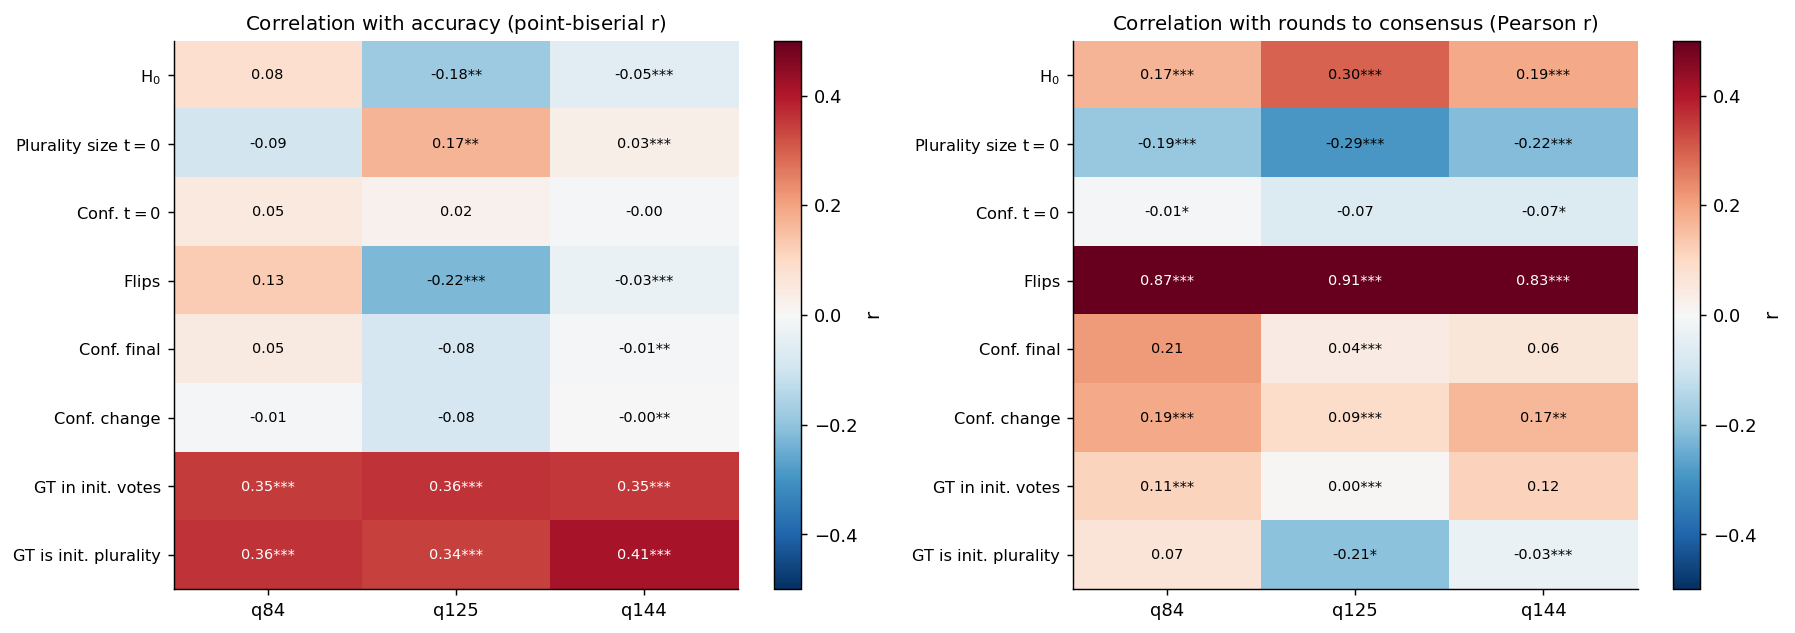

saved figA_correlation_heatmap.png


In [10]:
features   = ['h0','majority_size_0','mean_conf_0','n_flips',
             'mean_conf_final','conf_delta','gt_in_init_votes','gt_is_init_majority']
feat_labels = ['$H_0$','Plurality size $t=0$','Conf. $t=0$','Flips',
               'Conf. final','Conf. change','GT in init. votes','GT is init. plurality']

rows = []
for qid in TASKS:
    df = dfs[qid]
    for feat, label in zip(features, feat_labels):
        x = df[feat].values
        r_acc, p_acc = pointbiserialr(x, df['correct'].values)
        r_rnd, p_rnd = pearsonr(x, df['rounds'].values)
        rows.append({'qid': qid, 'feature': label,
                     'r_accuracy': r_acc, 'p_accuracy': p_acc,
                     'r_rounds': r_rnd, 'p_rounds': p_rnd})
corr_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (val_col, title) in zip(axes, [('r_accuracy', 'Correlation with accuracy (point-biserial $r$)'),
                                        ('r_rounds',   'Correlation with rounds to consensus (Pearson $r$)')]):
    piv = corr_df.pivot(index='feature', columns='qid', values=val_col).reindex(feat_labels)
    im = ax.imshow(piv.values, cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')
    no_grid(ax)
    ax.set_xticks(range(len(TASKS))); ax.set_xticklabels([f'q{q}' for q in TASKS])
    ax.set_yticks(range(len(feat_labels))); ax.set_yticklabels(feat_labels, fontsize=9)
    plt.colorbar(im, ax=ax, label='$r$')
    ax.set_title(title, fontsize=11)
    for i in range(len(feat_labels)):
        for j, qid in enumerate(TASKS):
            r = piv.values[i, j]
            p = corr_df[(corr_df.qid==qid) & (corr_df.feature==feat_labels[i])][
                'p_accuracy' if val_col=='r_accuracy' else 'p_rounds'].values[0]
            sig = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else ''
            ax.text(j, i, f'{r:.2f}{sig}', ha='center', va='center', fontsize=8,
                    color='white' if abs(r) > 0.3 else 'black')

plt.tight_layout()
fig.savefig(EXPORT / 'figA_correlation_heatmap.png')
plt.show()
print('saved figA_correlation_heatmap.png')

## 7. Summary statistics (for LaTeX table)

In [11]:
print('Summary statistics:\n')
for qid in TASKS:
    df = dfs[qid]
    y = df[df['gt_in_init_votes']==1]; n = df[df['gt_in_init_votes']==0]
    m = df[df['gt_is_init_majority']==1]; nm_v = df[(df['gt_in_init_votes']==1) & (df['gt_is_init_majority']==0)]
    print(f"q{qid}:")
    print(f"  R=1000  overall acc={df['correct'].mean():.3f}  "
          f"mean rounds={df['rounds'].mean():.2f}  std={df['rounds'].std():.2f}")
    print(f"  gt present in init. votes: {len(y)} runs ({len(y)/len(df)*100:.1f}%)  "
          f"acc={y['correct'].mean():.3f}")
    print(f"  gt absent from init. votes: {len(n)} runs ({len(n)/len(df)*100:.1f}%)  "
          f"acc={n['correct'].mean():.4f}")
    print(f"  gt IS init. plurality: {len(m)} runs  acc={m['correct'].mean():.3f}")
    print(f"  gt in votes but NOT plurality: {len(nm_v)} runs  acc={nm_v['correct'].mean():.3f}")
    r_rnd, _ = pearsonr(df['n_flips'], df['rounds'])
    print(f"  r(flips, rounds)={r_rnd:.3f}")
    print()

Summary statistics:

q84:
  R=1000  overall acc=0.269  mean rounds=4.52  std=1.57
  gt present in init. votes: 743 runs (74.3%)  acc=0.361
  gt absent from init. votes: 257 runs (25.7%)  acc=0.0039
  gt IS init. plurality: 213 runs  acc=0.620
  gt in votes but NOT plurality: 530 runs  acc=0.257
  r(flips, rounds)=0.830

q125:
  R=1000  overall acc=0.273  mean rounds=4.65  std=1.59
  gt present in init. votes: 707 runs (70.7%)  acc=0.373
  gt absent from init. votes: 293 runs (29.3%)  acc=0.0307
  gt IS init. plurality: 250 runs  acc=0.552
  gt in votes but NOT plurality: 457 runs  acc=0.276
  r(flips, rounds)=0.868

q144:
  R=1000  overall acc=0.509  mean rounds=4.22  std=1.46
  gt present in init. votes: 856 runs (85.6%)  acc=0.583
  gt absent from init. votes: 144 runs (14.4%)  acc=0.0694
  gt IS init. plurality: 403 runs  acc=0.717
  gt in votes but NOT plurality: 453 runs  acc=0.464
  r(flips, rounds)=0.915



## 8. Feature distributions split by outcome

KDE/histogram overlays for correct vs incorrect runs across each continuous
feature. Useful for spotting distributional separation before choosing additional
plots for the thesis.


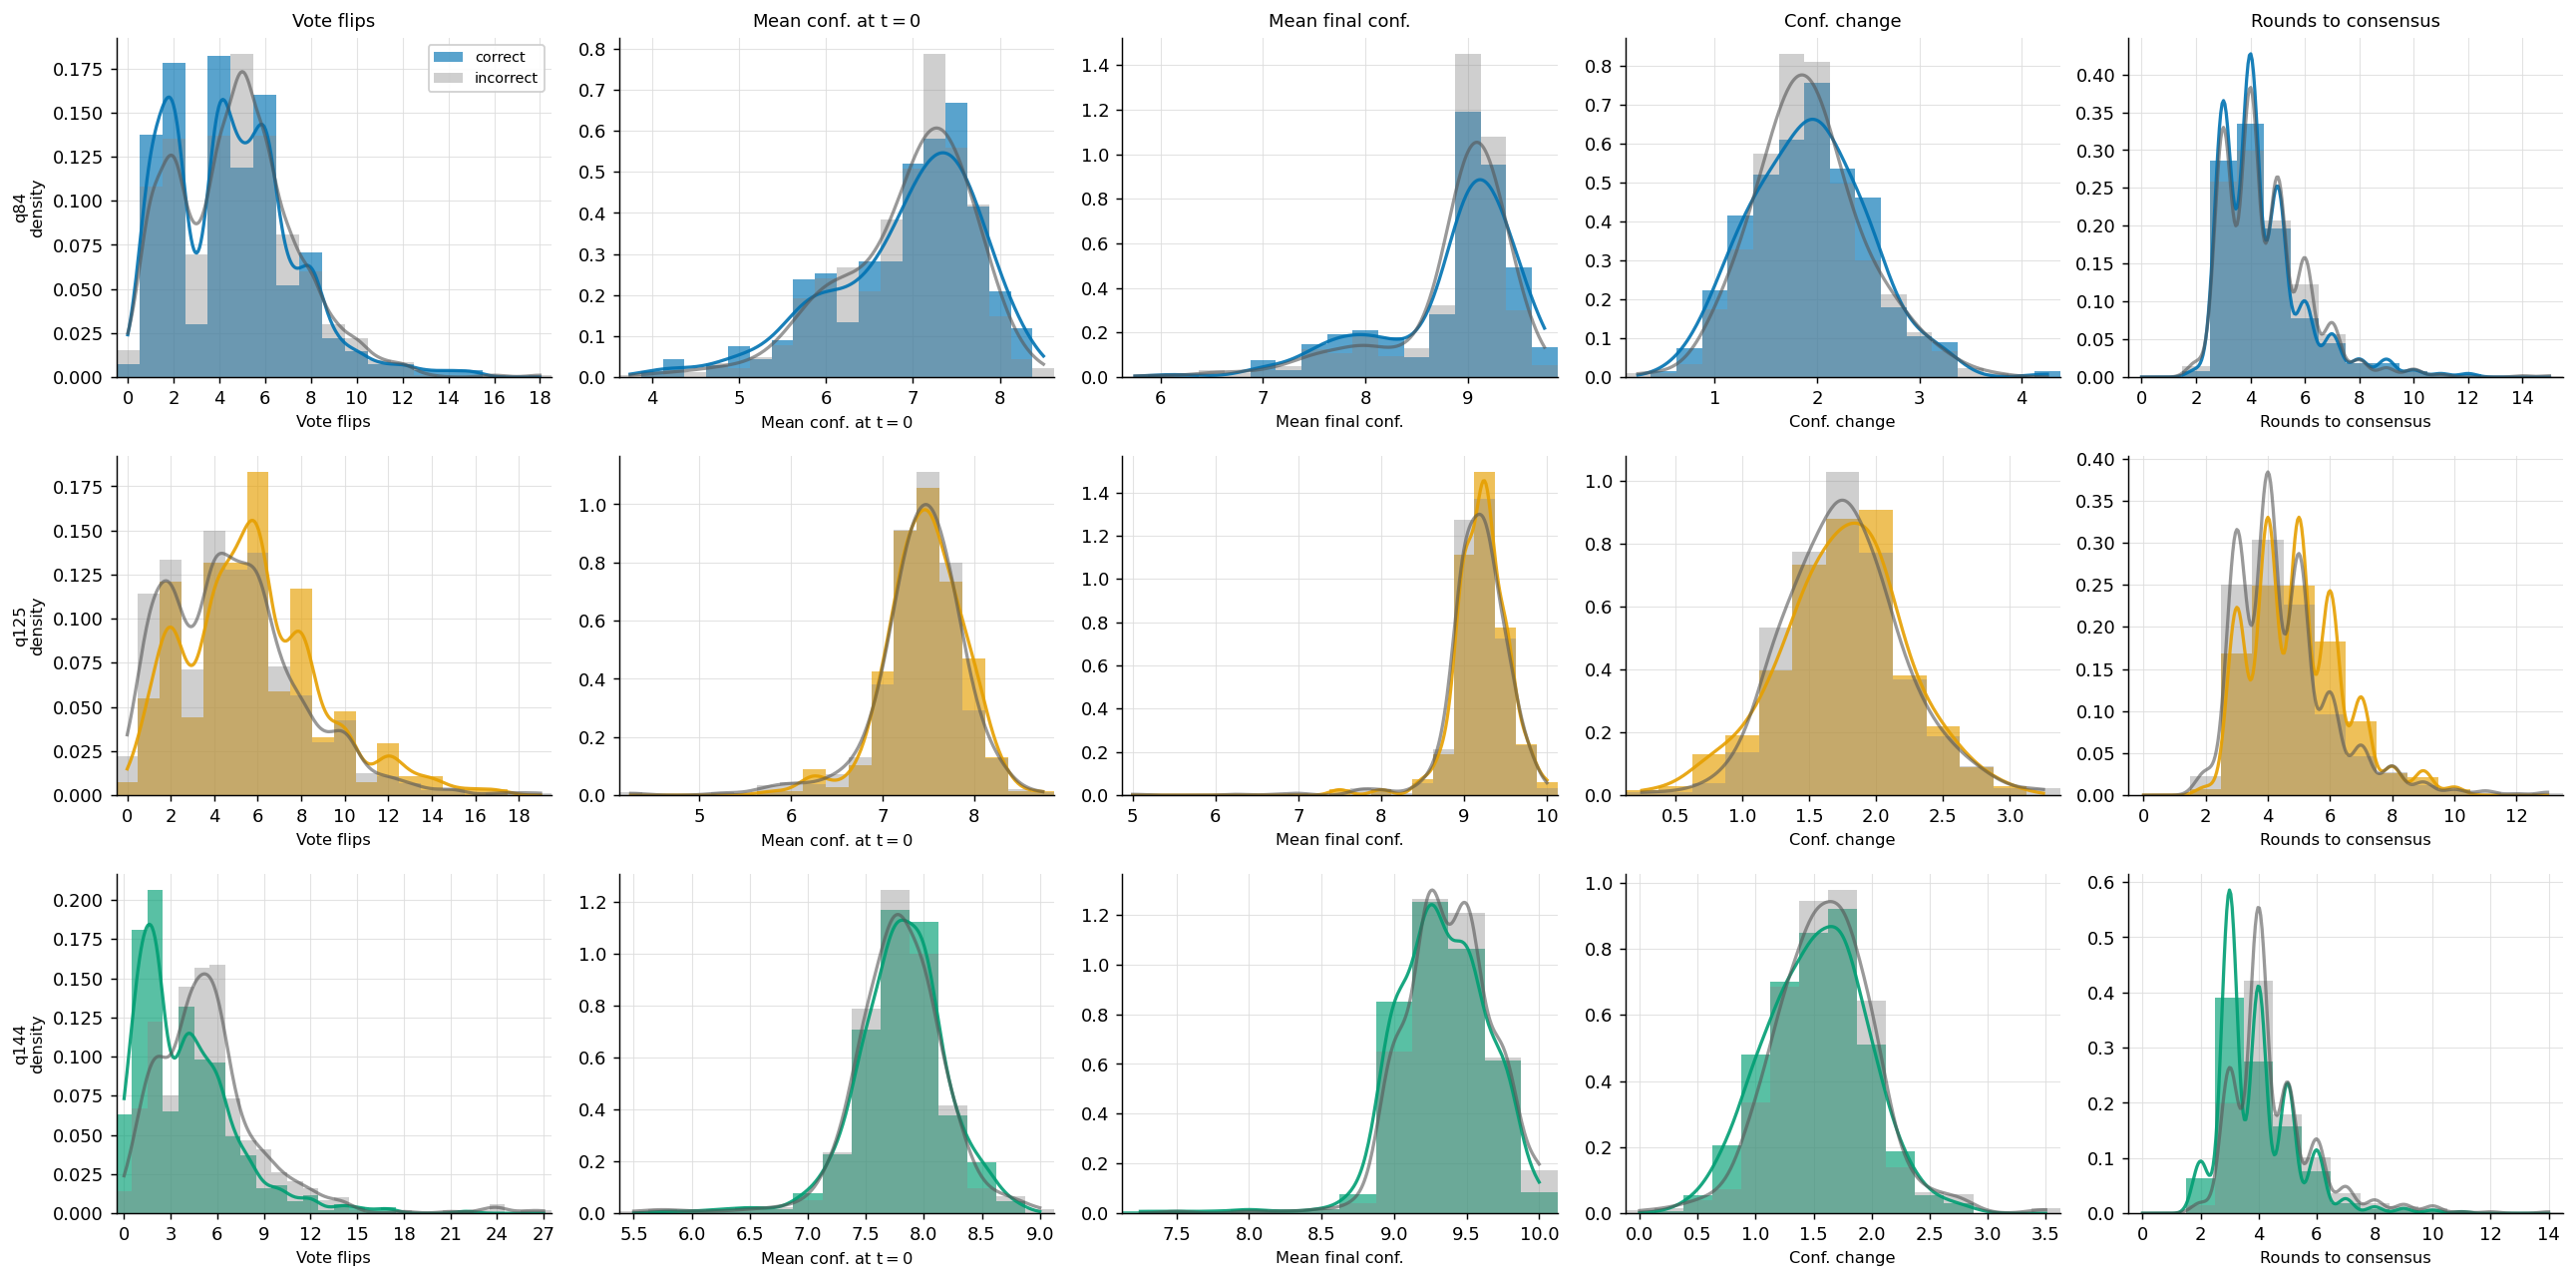

saved figA_distributions_by_outcome.png


In [12]:
feats_cont = [
    ('n_flips',         'Vote flips',              (0,    None)),
    ('mean_conf_0',     'Mean conf. at $t=0$',     (None, None)),
    ('mean_conf_final', 'Mean final conf.',         (None, None)),
    ('conf_delta',      'Conf. change',             (None, None)),
    ('rounds',          'Rounds to consensus',      (0,    None)),
]

fig, axes = plt.subplots(len(TASKS), len(feats_cont), figsize=(20, 10))

for row, qid in enumerate(TASKS):
    df = dfs[qid]
    df_c = df[df['correct'] == 1]
    df_w = df[df['correct'] == 0]

    for col, (feat, label, xlim) in enumerate(feats_cont):
        ax = axes[row][col]
        int_feat = feat in ('n_flips', 'rounds')
        # conf features are means of 4 integer values -> multiples of 0.25
        quarter_feat = feat in ('mean_conf_0', 'mean_conf_final', 'conf_delta')

        lo_x = xlim[0] if xlim[0] is not None else (
            int(df[feat].min()) if int_feat else float(df[feat].min()))
        hi_x = xlim[1] if xlim[1] is not None else (
            int(df[feat].max()) if int_feat else float(df[feat].max()))

        if int_feat:
            bins = np.arange(lo_x, hi_x + 2) - 0.5
        elif quarter_feat:
            step = 0.25
            bins = np.arange(lo_x - step/2, hi_x + step, step)
        else:
            bins = np.linspace(lo_x, hi_x, 25)

        ax.hist(df_c[feat].clip(lo_x, hi_x), bins=bins, density=True,
                color=COLORS[qid], alpha=0.65, label='correct')
        ax.hist(df_w[feat].clip(lo_x, hi_x), bins=bins, density=True,
                color='#888888', alpha=0.40, label='incorrect')

        # KDE overlay for all features
        xs = np.linspace(lo_x, hi_x, 300)
        for sub, color, alpha in [(df_c, COLORS[qid], 0.9), (df_w, '#555555', 0.6)]:
            if len(sub) > 10:
                try:
                    bw = 0.2 if int_feat else 0.35
                    kde = gaussian_kde(sub[feat].clip(lo_x, hi_x), bw_method=bw)
                    ax.plot(xs, kde(xs), color=color, lw=1.8, alpha=alpha)
                except Exception:
                    pass

        if int_feat:
            ax.set_xlim(lo_x - 0.5, hi_x + 0.5)
            from matplotlib.ticker import MaxNLocator
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        elif quarter_feat:
            ax.set_xlim(lo_x - 0.125, hi_x + 0.125)
        else:
            ax.set_xlim(lo_x, hi_x)
        ax.set_xlabel(label, fontsize=9)
        if row == 0:
            ax.set_title(label, fontsize=10)
        if col == 0:
            ax.set_ylabel(f'q{qid}\ndensity', fontsize=9)
        if row == 0 and col == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(EXPORT / 'figA_distributions_by_outcome.png')
plt.show()
print('saved figA_distributions_by_outcome.png')